# CRISP-DM Phase 3: Data Preparation

This notebook prepares model-ready data from the crash, vehicle, and people tables.

Outputs:
- crash-level route-risk features
- vehicle/person crash-context table
- grid-time baseline table
- scenario-layer baseline table

Official modeling target:
- zone-level severity-weighted crash risk (`severity_weight_sum`) on a grid cell and time window


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")


def find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "data").exists() and (candidate / "crisp_stages").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root")


ROOT = find_repo_root(Path.cwd())
DATA_DIR = ROOT / "data"
OUTPUT_DIR = ROOT / "generated" / "prepared"
CRASHES_PATH = DATA_DIR / "Traffic_Crashes_-_Crashes.csv"
VEHICLES_PATH = DATA_DIR / "Traffic_Crashes_-_Vehicles.csv"
PEOPLE_PATH = DATA_DIR / "Traffic_Crashes_-_People.csv"

MODELING_START_YEAR = 2018
MODELING_END_YEAR = 2025
CRASH_DATE_FMT = "%m/%d/%Y %I:%M:%S %p"

GRID_LAT_ORIGIN = 41.60
GRID_LON_ORIGIN = -87.95
GRID_LAT_STEP = 0.005
GRID_LON_STEP = 0.006

CHUNKSIZE = 100_000

official_target = "severity_weight_sum"

ROOT


PosixPath('/Users/avgreensoup/Desktop/innopolis-homeworks/Project_big_mine')

In [2]:
CRASH_USECOLS = [
    "CRASH_RECORD_ID",
    "CRASH_DATE",
    "POSTED_SPEED_LIMIT",
    "TRAFFIC_CONTROL_DEVICE",
    "DEVICE_CONDITION",
    "WEATHER_CONDITION",
    "LIGHTING_CONDITION",
    "TRAFFICWAY_TYPE",
    "LANE_CNT",
    "ALIGNMENT",
    "ROADWAY_SURFACE_COND",
    "ROAD_DEFECT",
    "INTERSECTION_RELATED_I",
    "WORK_ZONE_I",
    "WORK_ZONE_TYPE",
    "WORKERS_PRESENT_I",
    "HIT_AND_RUN_I",
    "FIRST_CRASH_TYPE",
    "LATITUDE",
    "LONGITUDE",
    "NUM_UNITS",
    "MOST_SEVERE_INJURY",
    "INJURIES_TOTAL",
    "INJURIES_FATAL",
    "INJURIES_INCAPACITATING",
    "INJURIES_NON_INCAPACITATING",
    "INJURIES_REPORTED_NOT_EVIDENT",
]

VEHICLE_USECOLS = [
    "CRASH_RECORD_ID",
    "CRASH_DATE",
    "UNIT_TYPE",
    "NUM_PASSENGERS",
    "OCCUPANT_CNT",
    "EXCEED_SPEED_LIMIT_I",
    "TOWED_I",
    "FIRE_I",
    "CMRC_VEH_I",
]

PEOPLE_USECOLS = [
    "CRASH_RECORD_ID",
    "CRASH_DATE",
    "PERSON_TYPE",
    "INJURY_CLASSIFICATION",
    "SEX",
    "AGE",
    "AIRBAG_DEPLOYED",
    "SAFETY_EQUIPMENT",
]

PREDICTOR_COLUMNS = [
    "CRASH_RECORD_ID",
    "crash_ts",
    "crash_year",
    "crash_month",
    "crash_day",
    "crash_hour",
    "day_of_week",
    "hour_of_week",
    "is_weekend",
    "is_rush_hour",
    "is_night",
    "season",
    "LATITUDE",
    "LONGITUDE",
    "grid_lat_idx",
    "grid_lon_idx",
    "grid_id",
    "grid_center_lat",
    "grid_center_lon",
    "POSTED_SPEED_LIMIT",
    "speed_limit_bin",
    "TRAFFIC_CONTROL_DEVICE",
    "DEVICE_CONDITION",
    "WEATHER_CONDITION",
    "LIGHTING_CONDITION",
    "TRAFFICWAY_TYPE",
    "LANE_CNT",
    "ALIGNMENT",
    "ROADWAY_SURFACE_COND",
    "ROAD_DEFECT",
    "INTERSECTION_RELATED_I",
    "WORK_ZONE_I",
    "WORK_ZONE_TYPE",
    "WORKERS_PRESENT_I",
    "is_rain",
    "is_snow",
    "is_dark",
    "is_wet_surface",
    "is_intersection",
    "is_work_zone",
]

TARGET_COLUMNS = [
    "injury_crash",
    "serious_injury_crash",
    "fatal_crash",
    "severity_weight",
]

LEAKAGE_COLUMNS = [
    "CRASH_TYPE",
    "FIRST_CRASH_TYPE",
    "PRIM_CONTRIBUTORY_CAUSE",
    "SEC_CONTRIBUTORY_CAUSE",
    "HIT_AND_RUN_I",
    "NUM_UNITS",
    "MOST_SEVERE_INJURY",
    "INJURIES_TOTAL",
    "INJURIES_FATAL",
    "INJURIES_INCAPACITATING",
    "INJURIES_NON_INCAPACITATING",
    "INJURIES_REPORTED_NOT_EVIDENT",
    "INJURIES_NO_INDICATION",
    "INJURIES_UNKNOWN",
]

VEHICLE_CONTEXT_COLUMNS = [
    "vehicle_rows",
    "vehicle_driver_rows",
    "vehicle_parked_rows",
    "vehicle_pedestrian_rows",
    "vehicle_bicycle_rows",
    "vehicle_driverless_rows",
    "vehicle_non_motor_rows",
    "vehicle_non_contact_rows",
    "vehicle_disabled_rows",
    "vehicle_equestrian_rows",
    "vehicle_occupant_cnt_sum",
    "vehicle_occupant_cnt_count",
    "vehicle_num_passengers_sum",
    "vehicle_num_passengers_count",
    "vehicle_speed_exceed_count",
    "vehicle_towed_count",
    "vehicle_fire_count",
    "vehicle_cmrc_count",
    "vehicle_occupant_cnt_mean",
    "vehicle_num_passengers_mean",
    "vehicle_speed_exceed_rate",
    "vehicle_towed_rate",
    "vehicle_fire_rate",
]

PEOPLE_CONTEXT_COLUMNS = [
    "person_rows",
    "person_driver_rows",
    "person_passenger_rows",
    "person_pedestrian_rows",
    "person_bicycle_rows",
    "person_non_motor_rows",
    "person_non_contact_rows",
    "person_male_rows",
    "person_female_rows",
    "person_age_sum",
    "person_age_count",
    "person_age_mean",
    "person_reported_not_evident_rows",
    "person_nonincapacitating_rows",
    "person_incapacitating_rows",
    "person_fatal_rows",
    "person_no_indication_rows",
    "person_airbag_deployed_rows",
    "person_severity_weight",
    "person_severe_injury_rows",
    "person_injury_any_rows",
    "person_injury_rate",
]

SCENARIO_NAMES = ["overall", "rain", "dark", "wet_surface", "rain_dark_wet", "pedbike"]


In [3]:
def normalize_category(series: pd.Series, missing: str = "MISSING") -> pd.Series:
    return (
        series.astype("string")
        .str.strip()
        .fillna(missing)
        .replace({"<NA>": missing, "nan": missing, "NaN": missing, "": missing})
    )


def season_from_month(month: pd.Series) -> pd.Series:
    mapping = {
        12: "winter", 1: "winter", 2: "winter",
        3: "spring", 4: "spring", 5: "spring",
        6: "summer", 7: "summer", 8: "summer",
        9: "autumn", 10: "autumn", 11: "autumn",
    }
    return month.map(mapping).astype("string")


def speed_limit_bin(speed_limit: pd.Series) -> pd.Series:
    bins = [-np.inf, 0, 15, 25, 30, 35, 45, np.inf]
    labels = ["0", "1-15", "16-25", "26-30", "31-35", "36-45", "46+"]
    return pd.cut(speed_limit, bins=bins, labels=labels)


def load_and_filter_crashes() -> pd.DataFrame:
    df = pd.read_csv(CRASHES_PATH, usecols=CRASH_USECOLS, low_memory=False)
    df["crash_ts"] = pd.to_datetime(df["CRASH_DATE"], format=CRASH_DATE_FMT, errors="coerce")
    df = df[df["crash_ts"].notna()].copy()
    df["crash_year"] = df["crash_ts"].dt.year
    df = df[df["crash_year"].between(MODELING_START_YEAR, MODELING_END_YEAR)].copy()
    df["LATITUDE"] = pd.to_numeric(df["LATITUDE"], errors="coerce")
    df["LONGITUDE"] = pd.to_numeric(df["LONGITUDE"], errors="coerce")
    valid_geo = df["LATITUDE"].between(41.60, 42.10) & df["LONGITUDE"].between(-87.95, -87.50)
    return df[valid_geo].copy()


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df["crash_month"] = df["crash_ts"].dt.month.astype("int16")
    df["crash_day"] = df["crash_ts"].dt.day.astype("int16")
    df["crash_hour"] = df["crash_ts"].dt.hour.astype("int16")
    df["day_of_week"] = df["crash_ts"].dt.dayofweek.astype("int16")
    df["hour_of_week"] = (df["day_of_week"] * 24 + df["crash_hour"]).astype("int16")
    df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype("int8")
    df["is_rush_hour"] = ((df["day_of_week"] <= 4) & df["crash_hour"].isin([7, 8, 9, 16, 17, 18])).astype("int8")
    df["is_night"] = df["crash_hour"].isin([20, 21, 22, 23, 0, 1, 2, 3, 4, 5]).astype("int8")
    df["season"] = season_from_month(df["crash_month"])
    df["POSTED_SPEED_LIMIT"] = pd.to_numeric(df["POSTED_SPEED_LIMIT"], errors="coerce").fillna(0)
    df["LANE_CNT"] = pd.to_numeric(df["LANE_CNT"], errors="coerce").fillna(-1).astype("int16")
    df["NUM_UNITS"] = pd.to_numeric(df["NUM_UNITS"], errors="coerce").fillna(-1).astype("int16")
    df["speed_limit_bin"] = speed_limit_bin(df["POSTED_SPEED_LIMIT"]).astype("string")
    for col in [
        "TRAFFIC_CONTROL_DEVICE", "DEVICE_CONDITION", "WEATHER_CONDITION", "LIGHTING_CONDITION",
        "TRAFFICWAY_TYPE", "ALIGNMENT", "ROADWAY_SURFACE_COND", "ROAD_DEFECT",
        "INTERSECTION_RELATED_I", "WORK_ZONE_I", "WORK_ZONE_TYPE", "WORKERS_PRESENT_I",
        "HIT_AND_RUN_I", "FIRST_CRASH_TYPE", "MOST_SEVERE_INJURY",
    ]:
        df[col] = normalize_category(df[col])
    df["grid_lat_idx"] = np.floor((df["LATITUDE"] - GRID_LAT_ORIGIN) / GRID_LAT_STEP).astype("int32")
    df["grid_lon_idx"] = np.floor((df["LONGITUDE"] - GRID_LON_ORIGIN) / GRID_LON_STEP).astype("int32")
    df["grid_id"] = df["grid_lat_idx"].astype("string") + "_" + df["grid_lon_idx"].astype("string")
    df["grid_center_lat"] = GRID_LAT_ORIGIN + (df["grid_lat_idx"] + 0.5) * GRID_LAT_STEP
    df["grid_center_lon"] = GRID_LON_ORIGIN + (df["grid_lon_idx"] + 0.5) * GRID_LON_STEP
    weather = df["WEATHER_CONDITION"]
    lighting = df["LIGHTING_CONDITION"]
    surface = df["ROADWAY_SURFACE_COND"]
    df["is_rain"] = weather.isin(["RAIN", "FREEZING RAIN/DRIZZLE"]).astype("int8")
    df["is_snow"] = weather.isin(["SNOW", "SLEET/HAIL", "BLOWING SNOW"]).astype("int8")
    df["is_dark"] = lighting.isin(["DARKNESS", "DARKNESS, LIGHTED ROAD", "DUSK", "DAWN"]).astype("int8")
    df["is_wet_surface"] = surface.isin(["WET", "SNOW OR SLUSH", "ICE"]).astype("int8")
    df["is_intersection"] = (df["INTERSECTION_RELATED_I"] == "Y").astype("int8")
    df["is_work_zone"] = (df["WORK_ZONE_I"] == "Y").astype("int8")
    df["is_hit_and_run"] = (df["HIT_AND_RUN_I"] == "Y").astype("int8")
    df["is_pedbike"] = df["FIRST_CRASH_TYPE"].isin(["PEDESTRIAN", "PEDALCYCLIST"]).astype("int8")
    injuries_total = pd.to_numeric(df["INJURIES_TOTAL"], errors="coerce").fillna(0)
    injuries_fatal = pd.to_numeric(df["INJURIES_FATAL"], errors="coerce").fillna(0)
    injuries_incap = pd.to_numeric(df["INJURIES_INCAPACITATING"], errors="coerce").fillna(0)
    injuries_nonincap = pd.to_numeric(df["INJURIES_NON_INCAPACITATING"], errors="coerce").fillna(0)
    injuries_reported = pd.to_numeric(df["INJURIES_REPORTED_NOT_EVIDENT"], errors="coerce").fillna(0)
    df["injury_crash"] = (injuries_total > 0).astype("int8")
    df["serious_injury_crash"] = ((injuries_fatal + injuries_incap) > 0).astype("int8")
    df["fatal_crash"] = (injuries_fatal > 0).astype("int8")
    df["severity_weight"] = (
        injuries_reported * 1.0 + injuries_nonincap * 2.0 + injuries_incap * 5.0 + injuries_fatal * 20.0
    ).astype("float32")
    return df


In [4]:
def chunked_groupby_sum(path: Path, usecols: list[str], builder) -> pd.DataFrame:
    parts = []
    for chunk in pd.read_csv(path, usecols=usecols, chunksize=CHUNKSIZE, low_memory=False):
        built = builder(chunk)
        if not built.empty:
            parts.append(built)
    if not parts:
        return pd.DataFrame(columns=["CRASH_RECORD_ID"])
    combined = pd.concat(parts, ignore_index=True)
    numeric_cols = [col for col in combined.columns if col != "CRASH_RECORD_ID"]
    return (
        combined.groupby("CRASH_RECORD_ID", as_index=False)[numeric_cols]
        .sum(min_count=1)
        .sort_values("CRASH_RECORD_ID")
        .reset_index(drop=True)
    )


def load_vehicle_context() -> pd.DataFrame:
    def build_chunk(chunk: pd.DataFrame) -> pd.DataFrame:
        chunk = chunk.copy()
        chunk["crash_ts"] = pd.to_datetime(chunk["CRASH_DATE"], format=CRASH_DATE_FMT, errors="coerce")
        chunk = chunk[chunk["crash_ts"].notna()].copy()
        chunk["crash_year"] = chunk["crash_ts"].dt.year
        chunk = chunk[chunk["crash_year"].between(MODELING_START_YEAR, MODELING_END_YEAR)].copy()

        unit_type = normalize_category(chunk["UNIT_TYPE"])
        chunk["vehicle_rows"] = 1
        chunk["vehicle_driver_rows"] = (unit_type == "DRIVER").astype("int16")
        chunk["vehicle_parked_rows"] = (unit_type == "PARKED").astype("int16")
        chunk["vehicle_pedestrian_rows"] = (unit_type == "PEDESTRIAN").astype("int16")
        chunk["vehicle_bicycle_rows"] = (unit_type == "BICYCLE").astype("int16")
        chunk["vehicle_driverless_rows"] = (unit_type == "DRIVERLESS").astype("int16")
        chunk["vehicle_non_motor_rows"] = (unit_type == "NON-MOTOR VEHICLE").astype("int16")
        chunk["vehicle_non_contact_rows"] = (unit_type == "NON-CONTACT VEHICLE").astype("int16")
        chunk["vehicle_disabled_rows"] = (unit_type == "DISABLED VEHICLE").astype("int16")
        chunk["vehicle_equestrian_rows"] = (unit_type == "EQUESTRIAN").astype("int16")

        chunk["vehicle_occupant_cnt"] = pd.to_numeric(chunk["OCCUPANT_CNT"], errors="coerce")
        chunk["vehicle_num_passengers"] = pd.to_numeric(chunk["NUM_PASSENGERS"], errors="coerce")
        chunk["vehicle_speed_exceed_flag"] = (normalize_category(chunk["EXCEED_SPEED_LIMIT_I"]) == "Y").astype("int16")
        chunk["vehicle_towed_flag"] = (normalize_category(chunk["TOWED_I"]) == "Y").astype("int16")
        chunk["vehicle_fire_flag"] = (normalize_category(chunk["FIRE_I"]) == "Y").astype("int16")
        chunk["vehicle_cmrc_flag"] = (normalize_category(chunk["CMRC_VEH_I"]) == "Y").astype("int16")

        return chunk.groupby("CRASH_RECORD_ID", as_index=False).agg(
            vehicle_rows=("vehicle_rows", "sum"),
            vehicle_driver_rows=("vehicle_driver_rows", "sum"),
            vehicle_parked_rows=("vehicle_parked_rows", "sum"),
            vehicle_pedestrian_rows=("vehicle_pedestrian_rows", "sum"),
            vehicle_bicycle_rows=("vehicle_bicycle_rows", "sum"),
            vehicle_driverless_rows=("vehicle_driverless_rows", "sum"),
            vehicle_non_motor_rows=("vehicle_non_motor_rows", "sum"),
            vehicle_non_contact_rows=("vehicle_non_contact_rows", "sum"),
            vehicle_disabled_rows=("vehicle_disabled_rows", "sum"),
            vehicle_equestrian_rows=("vehicle_equestrian_rows", "sum"),
            vehicle_occupant_cnt_sum=("vehicle_occupant_cnt", "sum"),
            vehicle_occupant_cnt_count=("vehicle_occupant_cnt", "count"),
            vehicle_num_passengers_sum=("vehicle_num_passengers", "sum"),
            vehicle_num_passengers_count=("vehicle_num_passengers", "count"),
            vehicle_speed_exceed_count=("vehicle_speed_exceed_flag", "sum"),
            vehicle_towed_count=("vehicle_towed_flag", "sum"),
            vehicle_fire_count=("vehicle_fire_flag", "sum"),
            vehicle_cmrc_count=("vehicle_cmrc_flag", "sum"),
        )

    context = chunked_groupby_sum(VEHICLES_PATH, VEHICLE_USECOLS, build_chunk)
    if context.empty:
        return context
    context["vehicle_occupant_cnt_mean"] = context["vehicle_occupant_cnt_sum"] / context["vehicle_occupant_cnt_count"].replace({0: np.nan})
    context["vehicle_num_passengers_mean"] = context["vehicle_num_passengers_sum"] / context["vehicle_num_passengers_count"].replace({0: np.nan})
    context["vehicle_speed_exceed_rate"] = context["vehicle_speed_exceed_count"] / context["vehicle_rows"].replace({0: np.nan})
    context["vehicle_towed_rate"] = context["vehicle_towed_count"] / context["vehicle_rows"].replace({0: np.nan})
    context["vehicle_fire_rate"] = context["vehicle_fire_count"] / context["vehicle_rows"].replace({0: np.nan})
    return context.sort_values("CRASH_RECORD_ID").reset_index(drop=True)


def load_people_context() -> pd.DataFrame:
    def build_chunk(chunk: pd.DataFrame) -> pd.DataFrame:
        chunk = chunk.copy()
        chunk["crash_ts"] = pd.to_datetime(chunk["CRASH_DATE"], format=CRASH_DATE_FMT, errors="coerce")
        chunk = chunk[chunk["crash_ts"].notna()].copy()
        chunk["crash_year"] = chunk["crash_ts"].dt.year
        chunk = chunk[chunk["crash_year"].between(MODELING_START_YEAR, MODELING_END_YEAR)].copy()

        person_type = normalize_category(chunk["PERSON_TYPE"])
        injury = normalize_category(chunk["INJURY_CLASSIFICATION"])
        sex = normalize_category(chunk["SEX"])
        airbag = normalize_category(chunk["AIRBAG_DEPLOYED"])
        age = pd.to_numeric(chunk["AGE"], errors="coerce")
        age = age.where(age.between(0, 110))

        chunk["person_rows"] = 1
        chunk["person_driver_rows"] = (person_type == "DRIVER").astype("int16")
        chunk["person_passenger_rows"] = (person_type == "PASSENGER").astype("int16")
        chunk["person_pedestrian_rows"] = (person_type == "PEDESTRIAN").astype("int16")
        chunk["person_bicycle_rows"] = (person_type == "BICYCLE").astype("int16")
        chunk["person_non_motor_rows"] = (person_type == "NON-MOTOR VEHICLE").astype("int16")
        chunk["person_non_contact_rows"] = (person_type == "NON-CONTACT VEHICLE").astype("int16")
        chunk["person_male_rows"] = (sex == "M").astype("int16")
        chunk["person_female_rows"] = (sex == "F").astype("int16")
        chunk["person_age_sum"] = age.fillna(0)
        chunk["person_age_count"] = age.notna().astype("int16")
        chunk["person_reported_not_evident_rows"] = (injury == "REPORTED, NOT EVIDENT").astype("int16")
        chunk["person_nonincapacitating_rows"] = (injury == "NONINCAPACITATING INJURY").astype("int16")
        chunk["person_incapacitating_rows"] = (injury == "INCAPACITATING INJURY").astype("int16")
        chunk["person_fatal_rows"] = (injury == "FATAL").astype("int16")
        chunk["person_no_indication_rows"] = (injury == "NO INDICATION OF INJURY").astype("int16")
        chunk["person_airbag_deployed_rows"] = airbag.str.contains("DEPLOYED", na=False).astype("int16")

        return chunk.groupby("CRASH_RECORD_ID", as_index=False).agg(
            person_rows=("person_rows", "sum"),
            person_driver_rows=("person_driver_rows", "sum"),
            person_passenger_rows=("person_passenger_rows", "sum"),
            person_pedestrian_rows=("person_pedestrian_rows", "sum"),
            person_bicycle_rows=("person_bicycle_rows", "sum"),
            person_non_motor_rows=("person_non_motor_rows", "sum"),
            person_non_contact_rows=("person_non_contact_rows", "sum"),
            person_male_rows=("person_male_rows", "sum"),
            person_female_rows=("person_female_rows", "sum"),
            person_age_sum=("person_age_sum", "sum"),
            person_age_count=("person_age_count", "sum"),
            person_reported_not_evident_rows=("person_reported_not_evident_rows", "sum"),
            person_nonincapacitating_rows=("person_nonincapacitating_rows", "sum"),
            person_incapacitating_rows=("person_incapacitating_rows", "sum"),
            person_fatal_rows=("person_fatal_rows", "sum"),
            person_no_indication_rows=("person_no_indication_rows", "sum"),
            person_airbag_deployed_rows=("person_airbag_deployed_rows", "sum"),
        )

    context = chunked_groupby_sum(PEOPLE_PATH, PEOPLE_USECOLS, build_chunk)
    if context.empty:
        return context
    context["person_age_mean"] = context["person_age_sum"] / context["person_age_count"].replace({0: np.nan})
    context["person_severity_weight"] = (
        context["person_reported_not_evident_rows"] * 1.0
        + context["person_nonincapacitating_rows"] * 2.0
        + context["person_incapacitating_rows"] * 5.0
        + context["person_fatal_rows"] * 20.0
    )
    context["person_severe_injury_rows"] = context["person_incapacitating_rows"] + context["person_fatal_rows"]
    context["person_injury_any_rows"] = context["person_rows"] - context["person_no_indication_rows"]
    context["person_injury_rate"] = context["person_injury_any_rows"] / context["person_rows"].replace({0: np.nan})
    return context.sort_values("CRASH_RECORD_ID").reset_index(drop=True)


def build_crash_feature_table(df: pd.DataFrame) -> pd.DataFrame:
    return df[PREDICTOR_COLUMNS + TARGET_COLUMNS].sort_values(["crash_ts", "CRASH_RECORD_ID"]).reset_index(drop=True)


def build_integrated_context_table(crashes: pd.DataFrame, vehicle_context: pd.DataFrame, people_context: pd.DataFrame) -> pd.DataFrame:
    base = crashes[
        [
            "CRASH_RECORD_ID",
            "crash_ts",
            "crash_year",
            "crash_month",
            "crash_hour",
            "grid_id",
            "grid_center_lat",
            "grid_center_lon",
            "injury_crash",
            "serious_injury_crash",
            "fatal_crash",
            "severity_weight",
        ]
    ].copy()
    base = base.merge(vehicle_context, on="CRASH_RECORD_ID", how="left", validate="1:1", indicator="vehicle_merge")
    base["has_vehicle_context"] = (base["vehicle_merge"] == "both").astype("int8")
    base = base.drop(columns=["vehicle_merge"])
    base = base.merge(people_context, on="CRASH_RECORD_ID", how="left", validate="1:1", indicator="people_merge")
    base["has_people_context"] = (base["people_merge"] == "both").astype("int8")
    base = base.drop(columns=["people_merge"])

    fill_zero_cols = [
        col for col in VEHICLE_CONTEXT_COLUMNS + PEOPLE_CONTEXT_COLUMNS + ["has_vehicle_context", "has_people_context"]
        if col in base.columns
    ]
    for col in fill_zero_cols:
        base[col] = base[col].fillna(0)

    base["vehicle_occupant_cnt_mean"] = base["vehicle_occupant_cnt_sum"] / base["vehicle_occupant_cnt_count"].replace({0: np.nan})
    base["vehicle_num_passengers_mean"] = base["vehicle_num_passengers_sum"] / base["vehicle_num_passengers_count"].replace({0: np.nan})
    base["vehicle_speed_exceed_rate"] = base["vehicle_speed_exceed_count"] / base["vehicle_rows"].replace({0: np.nan})
    base["vehicle_towed_rate"] = base["vehicle_towed_count"] / base["vehicle_rows"].replace({0: np.nan})
    base["vehicle_fire_rate"] = base["vehicle_fire_count"] / base["vehicle_rows"].replace({0: np.nan})
    base["person_age_mean"] = base["person_age_sum"] / base["person_age_count"].replace({0: np.nan})
    base["person_severity_weight"] = (
        base["person_reported_not_evident_rows"] * 1.0
        + base["person_nonincapacitating_rows"] * 2.0
        + base["person_incapacitating_rows"] * 5.0
        + base["person_fatal_rows"] * 20.0
    )
    base["person_severe_injury_rows"] = base["person_incapacitating_rows"] + base["person_fatal_rows"]
    base["person_injury_any_rows"] = base["person_rows"] - base["person_no_indication_rows"]
    base["person_injury_rate"] = base["person_injury_any_rows"] / base["person_rows"].replace({0: np.nan})
    return base.sort_values(["crash_ts", "CRASH_RECORD_ID"]).reset_index(drop=True)


def build_grid_time_baseline(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df.groupby(["grid_id", "grid_center_lat", "grid_center_lon", "crash_year", "crash_month", "crash_hour", "is_weekend"], dropna=False)
        .agg(
            crash_count=("CRASH_RECORD_ID", "size"),
            injury_crashes=("injury_crash", "sum"),
            serious_injury_crashes=("serious_injury_crash", "sum"),
            fatal_crashes=("fatal_crash", "sum"),
            severity_weight_sum=("severity_weight", "sum"),
            rain_share=("is_rain", "mean"),
            dark_share=("is_dark", "mean"),
            wet_surface_share=("is_wet_surface", "mean"),
            avg_speed_limit=("POSTED_SPEED_LIMIT", "mean"),
        )
        .reset_index()
        .sort_values(["crash_year", "crash_month", "crash_hour", "grid_id"])
    )


def build_scenario_layer(df: pd.DataFrame) -> pd.DataFrame:
    overall = (
        df.groupby(["grid_id", "grid_center_lat", "grid_center_lon"], dropna=False)
        .agg(
            overall_crash_count=("CRASH_RECORD_ID", "size"),
            overall_injury_crashes=("injury_crash", "sum"),
            overall_severity_weight=("severity_weight", "sum"),
        )
        .reset_index()
    )
    masks = {
        "overall": pd.Series(True, index=df.index),
        "rain": df["is_rain"] == 1,
        "dark": df["is_dark"] == 1,
        "wet_surface": df["is_wet_surface"] == 1,
        "rain_dark_wet": (df["is_rain"] == 1) & (df["is_dark"] == 1) & (df["is_wet_surface"] == 1),
        "pedbike": df["is_pedbike"] == 1,
    }
    parts = []
    for scenario_name, mask in masks.items():
        part = (
            df.loc[mask]
            .groupby(["grid_id", "grid_center_lat", "grid_center_lon"], dropna=False)
            .agg(
                crash_count=("CRASH_RECORD_ID", "size"),
                injury_crashes=("injury_crash", "sum"),
                serious_injury_crashes=("serious_injury_crash", "sum"),
                fatal_crashes=("fatal_crash", "sum"),
                severity_weight_sum=("severity_weight", "sum"),
            )
            .reset_index()
        )
        part["scenario_name"] = scenario_name
        parts.append(part)
    scenario_layer = pd.concat(parts, ignore_index=True)
    scenario_layer = scenario_layer.merge(overall, on=["grid_id", "grid_center_lat", "grid_center_lon"], how="left")
    scenario_layer["injury_rate"] = scenario_layer["injury_crashes"] / scenario_layer["crash_count"]
    scenario_layer["severity_per_crash"] = scenario_layer["severity_weight_sum"] / scenario_layer["crash_count"]
    scenario_layer["scenario_share_of_overall"] = scenario_layer["crash_count"] / scenario_layer["overall_crash_count"]
    return scenario_layer.sort_values(["scenario_name", "grid_id"]).reset_index(drop=True)


def build_metadata(
    crash_features: pd.DataFrame,
    vehicle_context: pd.DataFrame,
    people_context: pd.DataFrame,
    integrated_context: pd.DataFrame,
    grid_time: pd.DataFrame,
    scenario_layer: pd.DataFrame,
) -> dict:
    vehicle_match_rate = float(integrated_context["has_vehicle_context"].mean()) if len(integrated_context) else 0.0
    people_match_rate = float(integrated_context["has_people_context"].mean()) if len(integrated_context) else 0.0
    return {
        "source_files": {
            "crashes": str(CRASHES_PATH.relative_to(ROOT)),
            "vehicles": str(VEHICLES_PATH.relative_to(ROOT)),
            "people": str(PEOPLE_PATH.relative_to(ROOT)),
        },
        "official_target": {
            "name": "zone_level_severity_weighted_crash_risk",
            "column": official_target,
            "definition": "Sum of crash severity weights on a grid cell and time window.",
            "weights": {
                "reported_not_evident": 1,
                "non_incapacitating": 2,
                "incapacitating": 5,
                "fatal": 20,
            },
        },
        "modeling_window": {"start_year": MODELING_START_YEAR, "end_year": MODELING_END_YEAR},
        "spatial_unit": {
            "type": "grid", "approx_size_meters": 500,
            "lat_origin": GRID_LAT_ORIGIN, "lon_origin": GRID_LON_ORIGIN,
            "lat_step": GRID_LAT_STEP, "lon_step": GRID_LON_STEP,
        },
        "feature_engineering": {
            "safe_predictor_columns": PREDICTOR_COLUMNS,
            "target_columns": TARGET_COLUMNS,
            "excluded_leakage_columns": LEAKAGE_COLUMNS,
        },
        "integration": {
            "vehicle_context_columns": VEHICLE_CONTEXT_COLUMNS,
            "people_context_columns": PEOPLE_CONTEXT_COLUMNS,
            "vehicle_context_share": vehicle_match_rate,
            "people_context_share": people_match_rate,
            "vehicle_context_rows": int(len(vehicle_context)),
            "people_context_rows": int(len(people_context)),
            "integrated_context_rows": int(len(integrated_context)),
            "integration_note": "Vehicles and People are merged by CRASH_RECORD_ID as crash-context tables, not as direct route predictors.",
        },
        "target_decisions": {
            "official_target": "zone-level severity_weight_sum",
            "frequency_target": "crash_count aggregated by grid_id + crash_year + crash_month + crash_hour + is_weekend",
            "severity_target": "severity_weight_sum with weights 1*reported_not_evident + 2*non_incapacitating + 5*incapacitating + 20*fatal aggregated on the same grid-time unit",
            "scenario_layer_target": "grid-level aggregates for overall, rain, dark, wet_surface, rain_dark_wet, and pedbike layers",
        },
        "output_summary": {
            "crash_feature_rows": int(len(crash_features)),
            "vehicle_context_rows": int(len(vehicle_context)),
            "people_context_rows": int(len(people_context)),
            "integrated_context_rows": int(len(integrated_context)),
            "grid_time_rows": int(len(grid_time)),
            "scenario_layer_rows": int(len(scenario_layer)),
            "scenario_names": SCENARIO_NAMES,
        },
    }


def write_outputs(
    crash_features: pd.DataFrame,
    vehicle_context: pd.DataFrame,
    people_context: pd.DataFrame,
    integrated_context: pd.DataFrame,
    grid_time: pd.DataFrame,
    scenario_layer: pd.DataFrame,
) -> None:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    crash_features.to_csv(OUTPUT_DIR / "prepared_crash_features.csv.gz", index=False, compression="gzip")
    vehicle_context.to_csv(OUTPUT_DIR / "vehicle_context_by_crash.csv.gz", index=False, compression="gzip")
    people_context.to_csv(OUTPUT_DIR / "people_context_by_crash.csv.gz", index=False, compression="gzip")
    integrated_context.to_csv(OUTPUT_DIR / "integrated_crash_context.csv.gz", index=False, compression="gzip")
    grid_time.to_csv(OUTPUT_DIR / "baseline_grid_time.csv.gz", index=False, compression="gzip")
    scenario_layer.to_csv(OUTPUT_DIR / "baseline_scenario_layers.csv.gz", index=False, compression="gzip")
    metadata = build_metadata(crash_features, vehicle_context, people_context, integrated_context, grid_time, scenario_layer)
    (OUTPUT_DIR / "preparation_metadata.json").write_text(json.dumps(metadata, indent=2) + "\n")


## Run Preparation

This cell builds the prepared tables and writes them to `generated/prepared/`.

Vehicles and people are prepared as crash-context tables and merged by `CRASH_RECORD_ID`.


In [5]:
crashes = load_and_filter_crashes()
crashes = engineer_features(crashes)

vehicle_context = load_vehicle_context()
people_context = load_people_context()
integrated_context = build_integrated_context_table(crashes, vehicle_context, people_context)

crash_features = build_crash_feature_table(crashes)
grid_time = build_grid_time_baseline(crashes)
scenario_layer = build_scenario_layer(crashes)

write_outputs(crash_features, vehicle_context, people_context, integrated_context, grid_time, scenario_layer)

print(f"Crash features rows: {len(crash_features):,}")
print(f"Vehicle context rows: {len(vehicle_context):,}")
print(f"People context rows: {len(people_context):,}")
print(f"Integrated context rows: {len(integrated_context):,}")
print(f"Grid-time rows: {len(grid_time):,}")
print(f"Scenario rows: {len(scenario_layer):,}")


Crash features rows: 870,705
Vehicle context rows: 877,911
People context rows: 875,925
Integrated context rows: 870,705
Grid-time rows: 754,678
Scenario rows: 12,288


In [6]:
metadata = json.loads((OUTPUT_DIR / "preparation_metadata.json").read_text())
integration_summary = pd.DataFrame(
    {
        "table": ["crash_features", "vehicle_context", "people_context", "integrated_context"],
        "rows": [len(crash_features), len(vehicle_context), len(people_context), len(integrated_context)],
        "matched_crashes": [
            int(crash_features["CRASH_RECORD_ID"].nunique()),
            int(vehicle_context["CRASH_RECORD_ID"].nunique()),
            int(people_context["CRASH_RECORD_ID"].nunique()),
            int(integrated_context["CRASH_RECORD_ID"].nunique()),
        ],
    }
)

display(metadata)
display(integration_summary)


{'source_files': {'crashes': 'data/Traffic_Crashes_-_Crashes.csv',
  'vehicles': 'data/Traffic_Crashes_-_Vehicles.csv',
  'people': 'data/Traffic_Crashes_-_People.csv'},
 'official_target': {'name': 'zone_level_severity_weighted_crash_risk',
  'column': 'severity_weight_sum',
  'definition': 'Sum of crash severity weights on a grid cell and time window.',
  'weights': {'reported_not_evident': 1,
   'non_incapacitating': 2,
   'incapacitating': 5,
   'fatal': 20}},
 'modeling_window': {'start_year': 2018, 'end_year': 2025},
 'spatial_unit': {'type': 'grid',
  'approx_size_meters': 500,
  'lat_origin': 41.6,
  'lon_origin': -87.95,
  'lat_step': 0.005,
  'lon_step': 0.006},
 'feature_engineering': {'safe_predictor_columns': ['CRASH_RECORD_ID',
   'crash_ts',
   'crash_year',
   'crash_month',
   'crash_day',
   'crash_hour',
   'day_of_week',
   'hour_of_week',
   'is_weekend',
   'is_rush_hour',
   'is_night',
   'season',
   'LATITUDE',
   'LONGITUDE',
   'grid_lat_idx',
   'grid_lon_i

,table,rows,matched_crashes
0,crash_features,870705,870705
1,vehicle_context,877911,877911
2,people_context,875925,875925
3,integrated_context,870705,870705


In [7]:
scenario_summary = (
    scenario_layer.groupby("scenario_name", as_index=False)
    .agg(crash_count=("crash_count", "sum"), severity_weight_sum=("severity_weight_sum", "sum"))
)
scenario_summary


,scenario_name,crash_count,severity_weight_sum
0,dark,270282,152439.0
1,overall,870705,374137.0
2,pedbike,36947,77796.0
3,rain,74322,38958.0
4,rain_dark_wet,32911,20472.0
5,wet_surface,144762,67924.0


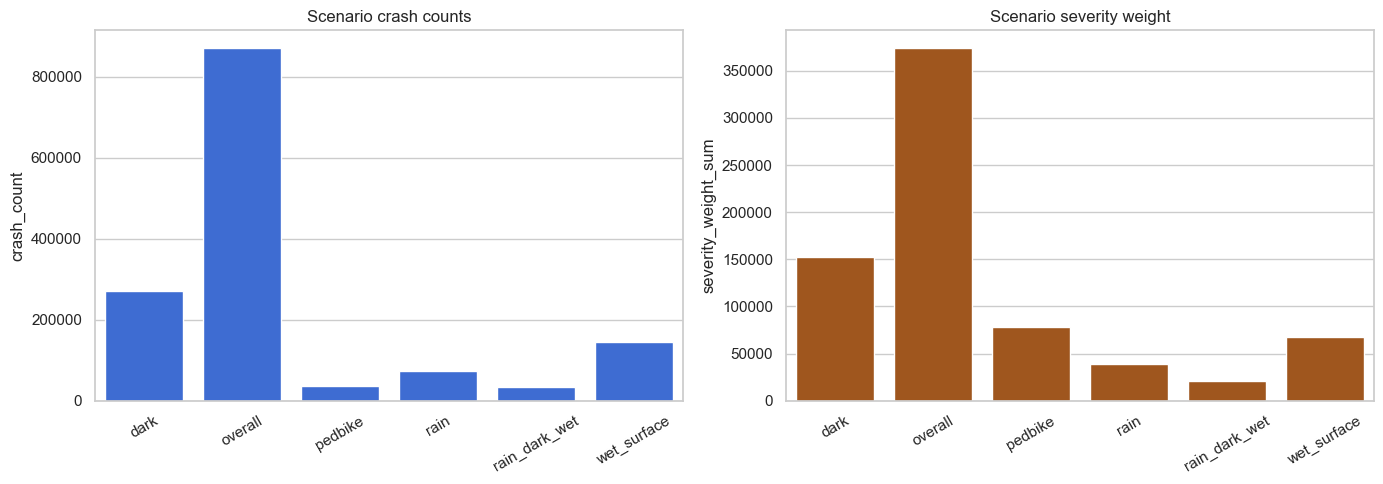

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=scenario_summary, x="scenario_name", y="crash_count", ax=axes[0], color="#2563eb")
axes[0].set_title("Scenario crash counts")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=scenario_summary, x="scenario_name", y="severity_weight_sum", ax=axes[1], color="#b45309")
axes[1].set_title("Scenario severity weight")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()


In [9]:
top_grids = scenario_layer.loc[scenario_layer["scenario_name"] == "overall", [
    "grid_id", "grid_center_lat", "grid_center_lon", "crash_count", "injury_rate", "severity_per_crash"
]].sort_values(["crash_count", "severity_per_crash"], ascending=False).head(15)
top_grids


,grid_id,grid_center_lat,grid_center_lon,crash_count,injury_rate,severity_per_crash
3480,58_52,41.8925,-87.635,4310,0.134571,0.361021
3482,58_54,41.8925,-87.623,4282,0.120972,0.283979
3481,58_53,41.8925,-87.629,3867,0.123093,0.313421
3340,53_51,41.8675,-87.641,3145,0.130684,0.351351
3454,57_54,41.8875,-87.623,2851,0.139951,0.414591
3453,57_53,41.8875,-87.629,2819,0.135509,0.405818
3425,56_53,41.8825,-87.629,2779,0.120187,0.291472
3424,56_52,41.8825,-87.635,2605,0.151631,0.411900
3398,55_53,41.8775,-87.629,2513,0.132113,0.357342
3426,56_54,41.8825,-87.623,2402,0.111157,0.290591
